In [15]:
# PS C:\Users\EmmaGolub\Desktop\MRoS_local> conda activate C:\Users\EmmaGolub\Desktop\MRoS_local\venv

"""
Resampling IMERG for ML predictors

Inputs
  - IMERG parquet already hourly after 'preprocessing.ipynb' with:
      time, lon, lat, plp
  - DEM_1km.tif defining the grid

Workflow
  - IMERG hourly parquet is resampled to align with 1 km fields
  - Output: NetCDF predictor cube (time , y, x)
"""

# Imports
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import rasterio
from rasterio.enums import Resampling
from pathlib import Path


In [16]:
# ----------------- Config ---------------------

date_suffix = "20221001_20260501"   # matches download_station_data.R output filenames

# ====================================================================
# REGION TOGGLE — change this to switch between CA and CO runs
# ====================================================================
REGION = "CO"   # "CA" = Sierra Nevada / Lake Tahoe
                 # "CO" = Colorado Mountains

REGION_CONFIG = {
    "CA": {
        "label":       "California: Sierra Nevada / Lake Tahoe",
        "utm_crs":     "EPSG:26911",   # UTM Zone 11N
        "dem_file":    "CA_DEM_AOI_1km.tif",
        "station_sub": "CA",
        "imerg_sub":   "CA",
        "aoi_lonlat": [
            (-119.45505750721992, 39.65343608043361),
            (-121.27878797084242, 39.66189413918429),
            (-119.11448133630248, 36.726935737063016),
            (-118.49924696303225, 37.235952484988736),
            (-119.46604383531404, 38.37304030164334),
        ],
    },
    "CO": {
        "label":       "Colorado Mountains",
        "utm_crs":     "EPSG:32613",   # UTM Zone 13N
        "dem_file":    "CO_DEM_AOI_1km.tif",
        "station_sub": "CO",
        "imerg_sub":   "CO",
        "aoi_lonlat": [
            (-105.19885928678391, 40.62046076499234),
            (-106.88927700287375, 40.555465783967925),
            (-107.66078646416787, 38.79540171139857),
            (-104.87856373593310, 38.77382201116306),
        ],
    },
}
rcfg = REGION_CONFIG[REGION]
print(f"Running region: {REGION} — {rcfg['label']}")

BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

OUT_DIR = BASE_DIR / f"outputs/resampled_grids/{REGION}"
print("OUT_DIR:", OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMERG_PARQUET = BASE_DIR / f"outputs/assimilated/{REGION}/hourly_data/imerg_hourly.parquet"
IMERG_OUT = OUT_DIR / "imerg_hourly_1km.nc"
print("IMERG_OUT:", IMERG_OUT)

DEM_PATH = BASE_DIR / f"Data/Elevation/{rcfg['dem_file']}"

Running region: CO — Colorado Mountains
BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\resampled_grids\CO
IMERG_OUT: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\resampled_grids\CO\imerg_hourly_1km.nc


In [17]:
# open DEM
with rasterio.open(DEM_PATH) as src:
    TEMPLATE_CRS = src.crs
    TEMPLATE_TRANSFORM = src.transform
    NY, NX = src.height, src.width

# IMERG resampling

In [18]:
# Load IMERG hourly parquet (already processed)

imerg = pd.read_parquet(IMERG_PARQUET)
imerg.head()
imerg.info()
imerg.describe()

imerg["hour_utc"] = pd.to_datetime(imerg["hour_utc"]).dt.floor("h")  # fix deprecation too

imerg_lons = np.sort(imerg["lon"].unique())
imerg_lats = np.sort(imerg["lat"].unique())[::-1]  # north → south
NXI = len(imerg_lons)
NYI = len(imerg_lats)

def imerg_to_xarray(df_hour, lats, lons):
    # Pivot handles missing lat/lon combos by filling NaN — no reshape needed
    pivot = df_hour.pivot_table(
        index="lat", columns="lon", values="plp", aggfunc="mean"
    )
    # Reindex to the full lat/lon grid (fills missing cells with NaN)
    pivot = pivot.reindex(index=lats, columns=lons)

    arr = pivot.to_numpy()   # shape is guaranteed (NYI, NXI)

    da = xr.DataArray(
        arr,
        dims=("lat", "lon"),
        coords={"lat": lats, "lon": lons},
        name="imerg_plp",
    )
    da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
    da = da.rio.write_crs("EPSG:4326", inplace=False)
    return da


imerg_hourly = []
for t in np.sort(imerg["hour_utc"].unique()):
    df_t = imerg[imerg["hour_utc"] == t]
    da = imerg_to_xarray(df_t, imerg_lats, imerg_lons)

    da_1km = da.rio.reproject(
        dst_crs=TEMPLATE_CRS,
        transform=TEMPLATE_TRANSFORM,
        shape=(NY, NX),
        resampling=Resampling.bilinear,
    )
    imerg_hourly.append(
        da_1km.to_dataset().assign_coords(time=t)
    )

imerg_hourly_1km = xr.concat(imerg_hourly, dim="time")
print(imerg_hourly_1km)

<class 'pandas.core.frame.DataFrame'>
Index: 9062400 entries, 30 to 13140446
Data columns (total 6 columns):
 #   Column    Dtype              
---  ------    -----              
 0   hour_utc  datetime64[ns, UTC]
 1   lat       float64            
 2   lon       float64            
 3   plp       float64            
 4   elev      float32            
 5   date      object             
dtypes: datetime64[ns, UTC](1), float32(1), float64(3), object(1)
memory usage: 449.4+ MB
<xarray.Dataset> Size: 9GB
Dimensions:      (time: 22656, y: 205, x: 242)
Coordinates:
  * x            (x) float64 2kB 2.694e+05 2.704e+05 ... 5.094e+05 5.104e+05
  * y            (y) float64 2kB 4.497e+06 4.496e+06 ... 4.294e+06 4.293e+06
    spatial_ref  int64 8B 0
  * time         (time) object 181kB 2022-10-01 00:00:00+00:00 ... 2025-05-01...
Data variables:
    imerg_plp    (time, y, x) float64 9GB nan nan nan nan ... nan nan nan nan


N valid pixels : 822,548,736  (73.2% non-NaN)
Mean           : 37.5923
Std            : 45.2883

Percentiles:
    0th : 0.0000
    1th : 0.0000
    5th : 0.0000
   25th : 0.0000
   50th : 4.7145
   75th : 100.0000
   95th : 100.0000
   99th : 100.0000
  100th : 100.0000

Fraction == 0  : 0.334  (33.4% dry)


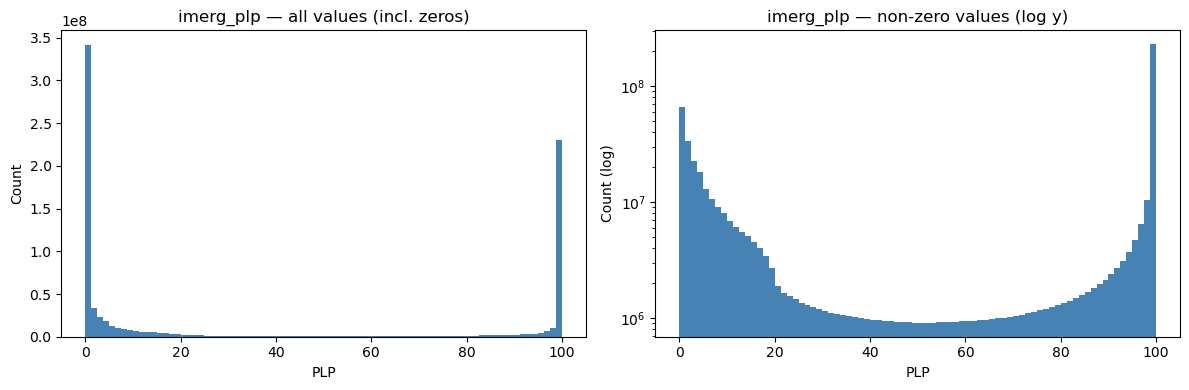

In [19]:
imerg_hourly_1km["imerg_plp"].min().item(), imerg_hourly_1km["imerg_plp"].max().item()

import numpy as np
import matplotlib.pyplot as plt

vals = imerg_hourly_1km["imerg_plp"].values.ravel()
vals_valid = vals[~np.isnan(vals)]

# --- numeric summary ---
percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
pct_vals = np.percentile(vals_valid, percentiles)

print(f"N valid pixels : {len(vals_valid):,}  ({100*len(vals_valid)/len(vals):.1f}% non-NaN)")
print(f"Mean           : {vals_valid.mean():.4f}")
print(f"Std            : {vals_valid.std():.4f}")
print()
print("Percentiles:")
for p, v in zip(percentiles, pct_vals):
    print(f"  {p:>3}th : {v:.4f}")

# --- fraction of zeros (dry hours/pixels) ---
frac_zero = (vals_valid == 0).mean()
print(f"\nFraction == 0  : {frac_zero:.3f}  ({100*frac_zero:.1f}% dry)")

# --- histogram (log-scale y, non-zero only) ---
nonzero = vals_valid[vals_valid > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(vals_valid, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("imerg_plp — all values (incl. zeros)")
axes[0].set_xlabel("PLP"); axes[0].set_ylabel("Count")

axes[1].hist(nonzero, bins=80, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("imerg_plp — non-zero values (log y)")
axes[1].set_xlabel("PLP"); axes[1].set_ylabel("Count (log)")

fig.tight_layout()
plt.show()

In [20]:
# Normalize time coordinates (drop tz)
imerg_hourly_1km_norm = imerg_hourly_1km.assign_coords(
    time=pd.to_datetime(imerg_hourly_1km.time.values).tz_localize(None)
)

In [21]:
# Write to netcdfs
imerg_enc = {
    v: {"zlib": True, "complevel": 4}
    for v in imerg_hourly_1km_norm.data_vars
}
imerg_hourly_1km_norm.to_netcdf(
    IMERG_OUT,
    format="NETCDF4",
    encoding=imerg_enc,
)
print(f"Wrote {IMERG_OUT}")


Wrote C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\resampled_grids\CO\imerg_hourly_1km.nc
